## Hyperfield Additive Table Generator and Isomorphism Analyzer

Welcome to this notebook! I've created this tool to explore quotient hyperfields of the form GF(p^k) / G_d, where G_d is a multiplicative subgroup of GF(p^k) of order `d`.

Here's what this notebook can do:

1.  **Generate Additive Tables:** You can input a prime `p`, an integer `k`, and a divisor `d` of `p^k - 1` to see the additive hyperoperation table for the resulting hyperfield.
2.  **Check for Isomorphism:** You can input parameters for two hyperfields and I can tell you if they are isomorphic.
3.  **Analyze and Visualize:** You can specify parameters to generate a range of potential hyperfields, classify them into isomorphism classes, and visualize the distribution of their characteristics and c-characteristics.

Let's get started!

### Requirements

To run this notebook, you'll need the following Python libraries. They are typically available in Colab or can be installed using `pip`:

-   Python 3.6+
-   pandas (`pip install pandas`)
-   galois (`pip install galois`)
-   matplotlib (`pip install matplotlib`)
-   numpy (`pip install numpy`)

### How it Works

Here's a brief overview of the process I've implemented:

1.  I use the `galois` library to construct finite fields GF(p^k).
2.  I identify a primitive element and construct the multiplicative subgroup of order `d`.
3.  I determine the coset representatives of GF(p^k)^*/G_d.
4.  I compute the additive hyperoperation based on Krasner's quotient construction for pairs of cosets (including the zero element).

For isomorphism checking, I compare structural properties of the hyperfields, specifically focusing on the multisets of sums involving the element [1] (the coset containing 1).

The analysis and visualization section automates the process of finding various hyperfields for a given size `n`, grouping them by isomorphism, calculating their characteristics, and showing the distribution of these characteristics.

### License

This project is licensed under the MIT License - see the [LICENSE](https://opensource.org/licenses/MIT) file for details.

Now, let's look at the core code. The next cell contains the complete Python script that handles the generation of additive tables, checking for isomorphism, generating triples (p, k, d) for a given size `n`, classifying hyperfields into isomorphism classes, analyzing their characteristics, and visualizing the distributions.

I've included all the necessary functions within this single cell for ease of use in this notebook environment.

In [ ]:
pip install galois

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 25.9 MB/s eta 0:00:00


In [ ]:
"""
Hyperfield additive table generator.

This module can generate the additive table for quotient hyperfields arising as
GF(p^k) / G_d, where G_d is the multiplicative subgroup of GF(p^k) of order d.

Requirements:
- pandas
- galois (pip install galois)

CLI usage:
- Run the module and input integers p, k, d such that p is prime, k >= 1, and d | (p^k - 1).
- The program constructs GF(p^k), builds the subgroup of order d, computes coset
  representatives of GF(p^k)^*/G_d, and prints the additive hyperoperation table including 0.

Notes and edge cases:
- Sorting and display: Field elements are cast to int for sorting when formatting cells.
  This reflects the vector-space representation chosen by galois (canonical integer mapping).
- For large fields or large d, the table can be very large; generation may be slow and memory intensive.
- If 'galois' is not installed, the generalized functionality will raise an ImportError.

Legacy (prime field) helpers for GF(p) modulo a subgroup of (Z/pZ)^* are retained below for reference.
"""

import pandas as pd
try:
    import galois
except ImportError as e:
    galois = None
try:
    from IPython.display import display as _ipython_display
    def display(obj):  # noqa: A001 - shadow built-in name intentionally for notebooks
        _ipython_display(obj)
except Exception:
    def display(obj):
        try:
            print(obj.to_string())
        except Exception:
            print(obj)

def is_prime(n):
    if n < 2:
        return False
    if n == 2:
        return True
    if n % 2 == 0:
        return False
    r = int(n**0.5)
    for i in range(3, r+1, 2):
        if n % i == 0:
            return False
    return True

def find_primitive_root(p):
    # Finds a primitive root modulo p (generator of the multiplicative group)
    # Works only for prime p
    if p == 2:
        return 1
    phi = p - 1
    factors = prime_factors(phi)
    for g in range(2, p):
        if all(pow(g, phi // f, p) != 1 for f in factors):
            return g
    raise ValueError("No primitive root found (should not happen for prime p)")

def prime_factors(n):
    # Returns a list of prime factors of n (without multiplicity)
    factors = []
    d = 2
    while d * d <= n:
        if n % d == 0:
            factors.append(d)
            while n % d == 0:
                n //= d
        d += 1 if d == 2 else 2
    if n > 1:
        factors.append(n)
    return factors

def construct_subgroup(p, d, g):
    # Constructs the subgroup G of order d generated by g^{(p-1)/d} mod p
    step = (p - 1) // d
    h = pow(g, step, p)
    subgroup = set(pow(h, i, p) for i in range(d))
    return subgroup

def coset_representatives(p, G, g):
    # Determine coset representatives for (Z/pZ)^*/G
    seen = set()
    reps = []
    for i in range(1, p):
        if i in seen:
            continue
        coset = {(i * x) % p for x in G}
        if not any(x in seen for x in coset):
            reps.append(i)
            seen |= coset
    return reps

def element_to_coset_idx(x, G, reps, p):
    if x == 0:
        return -1
    for idx, r in enumerate(reps):
        if any((r * g) % p == x for g in G):
            return idx
    raise ValueError(f"Element {x} not found in any coset")

def hyperaddition(p, G, reps, i, j):
    # Hyperaddition of cosets reps[i], reps[j]
    A = {(reps[i] * g) % p for g in G}
    B = {(reps[j] * g) % p for g in G}
    zero = 0
    result = set()
    for a in A:
        for b in B:
            s = (a + b) % p
            if s == zero:
                result.add(-1)
            else:
                result.add(element_to_coset_idx(s, G, reps, p))
    return result

def build_addition_table(p, G, reps):
    # Build addition table including zero element (-1)
    m = len(reps)
    # Use representatives in the table directly
    table = [[set() for _ in range(m + 1)] for _ in range(m + 1)]

    # Row/column headers based on representatives (including 0)
    headers = [0] + reps

    # Map coset index to representative
    idx_to_rep = {i: rep for i, rep in enumerate(reps)}
    idx_to_rep[-1] = 0

    for i in range(m + 1):
        for j in range(m + 1):
            if i == 0 and j == 0:
                table[i][j] = {0}
            elif i == 0:
                table[i][j] = {idx_to_rep[j-1]}
            elif j == 0:
                table[i][j] = {idx_to_rep[i-1]}
            else:
                result_indices = hyperaddition(p, G, reps, i-1, j-1)
                table[i][j] = {idx_to_rep[idx] for idx in result_indices}

    # Convert to pandas DataFrame for better visualization
    df_table = pd.DataFrame(table, index=[f"[{h}]" for h in headers], columns=[f"[{h}]" for h in headers])

    # Format the cells for readability
    def format_cell(cell_set):
        return "{" + ",".join([f"[{e}]" for e in sorted(cell_set)]) + "}"

    df_table = df_table.map(format_cell)

    return df_table

def format_cell_old(cell):
    return "{" + ",".join("0" if e == -1 else f"C{e}" for e in sorted(cell)) + "}"

def print_table_old(table):
    n = len(table) - 1
    headers = ["+"] + ["0"] + [f"C{i}" for i in range(n)]
    print('\t'.join(headers))
    for r in range(n + 1):
        row_label = "0" if r == 0 else f"C{r-1}"
        row_cells = [format_cell_old(table[r][c]) for c in range(n + 1)]
        print('\t'.join([row_label] + row_cells))

def hyper_sum_of_ones(p, G, reps, n_terms):
    # Compute 1⊞1⊞...⊞1 (n_terms)
    idx_1 = element_to_coset_idx(1, G, reps, p)
    # Need to build the table with original indices for calculation
    m = len(reps)
    table = [[set() for _ in range(m + 1)] for _ in range(m + 1)]
    for i in range(m + 1):
        table[0][i] = {i - 1} if i > 0 else {-1}
        table[i][0] = {i - 1} if i > 0 else {-1}
    for i in range(m):
        for j in range(m):
            table[i + 1][j + 1] = hyperaddition(p, G, reps, i, j)

    S = {idx_1}
    for _ in range(n_terms - 1):
        T = set()
        for a in S:
            row = a + 1 if a >= 0 else 0
            col = idx_1 + 1
            T |= table[row][col]
        S = T
    return S

def characteristic(p, G, reps, max_terms=2000):
    for n in range(1, max_terms + 1):
        if -1 in hyper_sum_of_ones(p, G, reps, n):
            return n
    return 0

def c_characteristic(p, G, reps, max_terms=2000):
    idx_1 = element_to_coset_idx(1, G, reps, p)
    for n in range(1, max_terms + 1):
        if idx_1 in hyper_sum_of_ones(p, G, reps, n + 1):
            return n
    return 0

# =====================
# Generalized with galois: GF(p^k) / G_d
# =====================

def validate_inputs(p, k, d):
    if not is_prime(p):
        raise ValueError("p must be prime")
    if k <= 0:
        raise ValueError("k must be a positive integer")
    if d <= 0:
        raise ValueError("d must be a positive integer")

def build_field_and_subgroup(p, k, d):
    if galois is None:
        raise ImportError("The 'galois' library is required. Install with 'pip install galois'.")
    validate_inputs(p, k, d)
    q = p ** k
    if (q - 1) % d != 0:
        raise ValueError(f"d must divide p^k - 1 = {q - 1}")
    GF = galois.GF(q)
    alpha = GF.primitive_element
    step = (q - 1) // d
    h = alpha ** step
    # Represent subgroup elements by their integer keys for hashing
    subgroup_keys = set(int(h ** i) for i in range(d))
    return GF, subgroup_keys

def gf_coset_representatives(GF, subgroup_keys):
    # Work with integer keys 1..q-1 to avoid unhashable GF elements
    q = GF.order
    seen_keys = set()
    reps_keys = []
    # Iterate starting from 1 to ensure the coset containing 1 is added first
    order = list(range(1, q))
    order.sort(key=lambda t: 0 if t == 1 else 1)
    for key in order:
        if key in seen_keys:
            continue
        # Coset as integer keys
        coset_keys = set(int(GF(key) * GF(gk)) for gk in subgroup_keys)
        if not any(ck in seen_keys for ck in coset_keys):
            reps_keys.append(key)
            seen_keys |= coset_keys
    # Return GF elements for display but we will still use keys internally elsewhere
    return [GF(k) for k in reps_keys]

def build_element_to_coset_index(GF, subgroup_keys, reps):
    # Map integer keys of field elements to coset index
    mapping = {}
    for idx, r in enumerate(reps):
        r_key = int(r)
        for gk in subgroup_keys:
            elem_key = int(GF(r_key) * GF(gk))
            mapping[elem_key] = idx
    return mapping

def gf_hyperaddition(GF, subgroup_keys, reps, element_to_idx, i, j):
    zero_key = 0
    r_i_key = int(reps[i])
    r_j_key = int(reps[j])
    A_keys = set(int(GF(r_i_key) * GF(gk)) for gk in subgroup_keys)
    B_keys = set(int(GF(r_j_key) * GF(gk)) for gk in subgroup_keys)
    result_indices = set()
    for a_key in A_keys:
        for b_key in B_keys:
            s_key = int(GF(a_key) + GF(b_key))
            if s_key == zero_key:
                result_indices.add(-1)
            else:
                result_indices.add(element_to_idx[s_key])
    return result_indices

def build_addition_table_gf(GF, subgroup_keys, reps):
    m = len(reps)
    element_to_idx = build_element_to_coset_index(GF, subgroup_keys, reps)
    # Use integer keys internally; 0 denotes zero element
    table = [[set() for _ in range(m + 1)] for _ in range(m + 1)]
    rep_keys = [int(r) for r in reps]
    # Headers are labels for readability
    def label_of_key(k):
        if k == 0:
            return "0"
        if k == 1:
            return "1"
        return str(GF(k))
    headers_labels = ["0"] + [label_of_key(k) for k in rep_keys]
    for i in range(m + 1):
        for j in range(m + 1):
            if i == 0 and j == 0:
                table[i][j] = {0}
            elif i == 0:
                table[i][j] = {rep_keys[j - 1]}
            elif j == 0:
                table[i][j] = {rep_keys[i - 1]}
            else:
                result_indices = gf_hyperaddition(GF, subgroup_keys, reps, element_to_idx, i - 1, j - 1)
                # Map coset indices to representative keys
                result_keys = set(rep_keys[idx] if idx >= 0 else 0 for idx in result_indices)
                table[i][j] = result_keys
    df_table = pd.DataFrame(table, index=[f"[{h}]" for h in headers_labels], columns=[f"[{h}]" for h in headers_labels])
    def format_cell(cell_set):
        return "{" + ",".join([f"[{label_of_key(k)}]" for k in sorted(cell_set)]) + "}"
    df_table = df_table.map(format_cell)
    return df_table

def gf_index_of_one(GF, subgroup_keys, reps):
    element_to_idx = build_element_to_coset_index(GF, subgroup_keys, reps)
    return element_to_idx[int(GF(1))]

def gf_hyper_sum_of_ones(GF, subgroup_keys, reps, n_terms):
    element_to_idx = build_element_to_coset_index(GF, subgroup_keys, reps)
    idx_1 = element_to_idx[int(GF(1))]
    S = {idx_1}
    for _ in range(n_terms - 1):
        T = set()
        for a in S:
            if a == -1:
                T.add(idx_1)
            else:
                T |= gf_hyperaddition(GF, subgroup_keys, reps, element_to_idx, a, idx_1)
        S = T
    return S

def gf_characteristic(GF, subgroup_keys, reps, max_terms=2000):
    for n in range(1, max_terms + 1):
        if -1 in gf_hyper_sum_of_ones(GF, subgroup_keys, reps, n):
            return n
    return 0

def gf_c_characteristic(GF, subgroup_keys, reps, max_terms=2000):
    idx_1 = gf_index_of_one(GF, subgroup_keys, reps)
    for n in range(1, max_terms + 1):
        if idx_1 in gf_hyper_sum_of_ones(GF, subgroup_keys, reps, n + 1):
            return n
    return 0

def main():
    while True:
        try:
            p = int(input("Enter a prime number p: "))
            k = int(input("Enter an integer k >= 1: "))
            validate_inputs(p, k, 1)
            q = p ** k
            print(f"p^k - 1 = {q - 1}")
            d = int(input(f"Enter divisor d of {q - 1}: "))
            if d <= 0 or (q - 1) % d != 0:
                print(f"d must divide {q - 1}. Try again.")
                continue
            break
        except ValueError as e:
            print(f"Invalid input: {e}")

    # Build GF(p^k) and subgroup of order d
    GF, subgroup_keys = build_field_and_subgroup(p, k, d)
    reps = gf_coset_representatives(GF, subgroup_keys)

    print(f"Field GF({p}^{k}) has order {p ** k}. Subgroup order d = {d}.")
    print(f"Coset representatives count: {len(reps)} (total quotient hyperfield order {len(reps) + 1})")

    table_df = build_addition_table_gf(GF, subgroup_keys, reps)
    print("Additive hyperoperation table (+):")
    display(table_df)

    # Optional: generalized characteristics via hyper-sums can be implemented similarly if needed
    char = gf_characteristic(GF, subgroup_keys, reps)
    cchar = gf_c_characteristic(GF, subgroup_keys, reps)
    print(f"Characteristic: {char}")
    print(f"C-characteristic: {cchar}")

if __name__ == "__main__":
    main()


Enter a prime number p: 7
Enter an integer k >= 1: 2
p^k - 1 = 48
Enter divisor d of 48: 12
Field GF(7^2) has order 49. Subgroup order d = 12.
Coset representatives count: 4 (total quotient hyperfield order 5)
Additive hyperoperation table (+):


,[0],[1],[7],[9],[12]
[0],{[0]},{[1]},{[7]},{[9]},{[12]}
[1],{[1]},"{[0],[1],[7],[9],[12]}","{[1],[7],[9],[12]}","{[1],[7],[9],[12]}","{[1],[7],[9],[12]}"
[7],{[7]},"{[1],[7],[9],[12]}","{[0],[1],[7],[9],[12]}","{[1],[7],[9],[12]}","{[1],[7],[9],[12]}"
[9],{[9]},"{[1],[7],[9],[12]}","{[1],[7],[9],[12]}","{[0],[1],[7],[9],[12]}","{[1],[7],[9],[12]}"
[12],{[12]},"{[1],[7],[9],[12]}","{[1],[7],[9],[12]}","{[1],[7],[9],[12]}","{[0],[1],[7],[9],[12]}"


Characteristic: 2
C-characteristic: 1


The next code cell contains the complete script to generate the additive table for quotient hyperfields GF(p^k)/G_d and to check for isomorphism between two such hyperfields. It includes all necessary function definitions (`is_prime`, `build_field_and_subgroup`, `check_isomorphism_generalized`, etc.) and a `main` function for interactive use.

In [ ]:
"""
Hyperfield additive table generator and isomorphism checker.

This module contains functions to:
1. Generate the additive table for quotient hyperfields arising as GF(p^k) / G_d,
   where G_d is the multiplicative subgroup of GF(p^k) of order d.
2. Check if two such quotient hyperfields are isomorphic.

Requirements:
- pandas
- galois (pip install galois)

CLI usage:
- Run the module and input integers p, k, d such that p is prime, k >= 1, and d | (p^k - 1).
- The program constructs GF(p^k), builds the subgroup of order d, computes coset
  representatives of GF(p^k)^*/G_d, and prints the additive hyperoperation table including 0.
- The program then prompts for inputs for a second hyperfield to check for isomorphism.

Notes and edge cases:
- Sorting and display: Field elements are cast to int for sorting when formatting cells.
  This reflects the vector-space representation chosen by galois (canonical integer mapping).
- For large fields or large d, the table can be very large; generation may be slow and memory intensive.
- If 'galois' is not installed, the generalized functionality will raise an ImportError.
"""

import pandas as pd
try:
    import galois
except ImportError as e:
    galois = None
try:
    from IPython.display import display as _ipython_display
    def display(obj):  # noqa: A001 - shadow built-in name intentionally for notebooks
        _ipython_display(obj)
except Exception:
    def display(obj):
        try:
            print(obj.to_string())
        except Exception:
            print(obj)

def is_prime(n):
    if n < 2:
        return False
    if n == 2:
        return True
    if n % 2 == 0:
        return False
    r = int(n**0.5)
    for i in range(3, r+1, 2):
        if n % i == 0:
            return False
    return True

def find_primitive_root(p):
    # Finds a primitive root modulo p (generator of the multiplicative group)
    # Works only for prime p
    if p == 2:
        return 1
    phi = p - 1
    factors = prime_factors(phi)
    for g in range(2, p):
        if all(pow(g, phi // f, p) != 1 for f in factors):
            return g
    raise ValueError("No primitive root found (should not happen for prime p)")

def prime_factors(n):
    # Returns a list of prime factors of n (without multiplicity)
    factors = []
    d = 2
    while d * d <= n:
        if n % d == 0:
            factors.append(d)
            while n % d == 0:
                n //= d
        d += 1 if d == 2 else 2
    if n > 1:
        factors.append(n)
    return factors

def construct_subgroup(p, d, g):
    # Constructs the subgroup G of order d generated by g^{(p-1)/d} mod p
    step = (p - 1) // d
    h = pow(g, step, p)
    subgroup = set(pow(h, i, p) for i in range(d))
    return subgroup

def coset_representatives(p, G, g):
    # Determine coset representatives for (Z/pZ)^*/G
    seen = set()
    reps = []
    for i in range(1, p):
        if i in seen:
            continue
        coset = {(i * x) % p for x in G}
        if not any(x in seen for x in coset):
            reps.append(i)
            seen |= coset
    return reps

def element_to_coset_idx(x, G, reps, p):
    if x == 0:
        return -1
    for idx, r in enumerate(reps):
        if any((r * g) % p == x for g in G):
            return idx
    raise ValueError(f"Element {x} not found in any coset")

def hyperaddition(p, G, reps, i, j):
    # Hyperaddition of cosets reps[i], reps[j]
    A = {(reps[i] * g) % p for g in G}
    B = {(reps[j] * g) % p for g in G}
    zero = 0
    result = set()
    for a in A:
        for b in B:
            s = (a + b) % p
            if s == zero:
                result.add(-1)
            else:
                result.add(element_to_coset_idx(s, G, reps, p))
    return result

def build_addition_table(p, G, reps):
    # Build addition table including zero element (-1)
    m = len(reps)
    # Use representatives in the table directly
    table = [[set() for _ in range(m + 1)] for _ in range(m + 1)]

    # Row/column headers based on representatives (including 0)
    headers = [0] + reps

    # Map coset index to representative
    idx_to_rep = {i: rep for i, rep in enumerate(reps)}
    idx_to_rep[-1] = 0

    for i in range(m + 1):
        for j in range(m + 1):
            if i == 0 and j == 0:
                table[i][j] = {0}
            elif i == 0:
                table[i][j] = {idx_to_rep[j-1]}
            elif j == 0:
                table[i][j] = {idx_to_rep[i-1]}
            else:
                result_indices = hyperaddition(p, G, reps, i-1, j-1)
                result_keys = set(idx_to_rep[idx] for idx in result_indices)
                table[i][j] = result_keys

    # Convert to pandas DataFrame for better visualization
    df_table = pd.DataFrame(table, index=[f"[{h}]" for h in headers], columns=[f"[{h}]" for h in headers])

    # Format the cells for readability
    def format_cell(cell_set):
        return "{" + ",".join([f"[{e}]" for e in sorted(cell_set)]) + "}"

    df_table = df_table.map(format_cell)

    return df_table

def format_cell_old(cell):
    return "{" + ",".join("0" if e == -1 else f"C{e}" for e in sorted(cell)) + "}"

def print_table_old(table):
    n = len(table) - 1
    headers = ["+"] + ["0"] + [f"C{i}" for i in range(n)]
    print('\t'.join(headers))
    for r in range(n + 1):
        row_label = "0" if r == 0 else f"C{r-1}"
        row_cells = [format_cell_old(table[r][c]) for c in range(n + 1)]
        print('\t'.join([row_label] + row_cells))

def hyper_sum_of_ones(p, G, reps, n_terms):
    # Compute 1⊞1⊞...⊞1 (n_terms)
    idx_1 = element_to_coset_idx(1, G, reps, p)
    # Need to build the table with original indices for calculation
    m = len(reps)
    table = [[set() for _ in range(m + 1)] for _ in range(m + 1)]
    for i in range(m + 1):
        table[0][i] = {i - 1} if i > 0 else {-1}
        table[i][0] = {i - 1} if i > 0 else {-1}
    for i in range(m):
        for j in range(m):
            table[i + 1][j + 1] = hyperaddition(p, G, reps, i, j)

    S = {idx_1}
    for _ in range(n_terms - 1):
        T = set()
        for a in S:
            row = a + 1 if a >= 0 else 0
            col = idx_1 + 1
            T |= table[row][col]
        S = T
    return S

def characteristic(p, G, reps, max_terms=2000):
    for n in range(1, max_terms + 1):
        if -1 in hyper_sum_of_ones(p, G, reps, n):
            return n
    return 0

def c_characteristic(p, G, reps, max_terms=2000):
    idx_1 = element_to_coset_idx(1, G, reps, p)
    for n in range(1, max_terms + 1):
        if idx_1 in hyper_sum_of_ones(p, G, reps, n + 1):
            return n
    return 0

# =====================
# Generalized with galois: GF(p^k) / G_d
# =====================

def validate_inputs(p, k, d):
    if not is_prime(p):
        raise ValueError("p must be prime")
    if k <= 0:
        raise ValueError("k must be a positive integer")
    if d <= 0:
        raise ValueError("d must be a positive integer")

def build_field_and_subgroup(p, k, d):
    if galois is None:
        raise ImportError("The 'galois' library is required. Install with 'pip install galois'.")
    validate_inputs(p, k, d)
    q = p ** k
    if (q - 1) % d != 0:
        raise ValueError(f"d must divide p^k - 1 = {q - 1}")
    GF = galois.GF(q)
    alpha = GF.primitive_element
    step = (q - 1) // d
    h = alpha ** step
    # Represent subgroup elements by their integer keys for hashing
    subgroup_keys = set(int(h ** i) for i in range(d))
    return GF, subgroup_keys

def gf_coset_representatives(GF, subgroup_keys):
    # Work with integer keys 1..q-1 to avoid unhashable GF elements
    q = GF.order
    seen_keys = set()
    reps_keys = []
    # Iterate starting from 1 to ensure the coset containing 1 is added first
    order = list(range(1, q))
    order.sort(key=lambda t: 0 if t == 1 else 1)
    for key in order:
        if key in seen_keys:
            continue
        # Coset as integer keys
        coset_keys = set(int(GF(key) * GF(gk)) for gk in subgroup_keys)
        if not any(ck in seen_keys for ck in coset_keys):
            reps_keys.append(key)
            seen_keys |= coset_keys
    # Return GF elements for display but we will still use keys internally elsewhere
    return [GF(k) for k in reps_keys]

def build_element_to_coset_index(GF, subgroup_keys, reps):
    # Map integer keys of field elements to coset index
    mapping = {}
    for idx, r in enumerate(reps):
        r_key = int(r)
        for gk in subgroup_keys:
            elem_key = int(GF(r_key) * GF(gk))
            mapping[elem_key] = idx
    return mapping

def gf_hyperaddition(GF, subgroup_keys, reps, element_to_idx, i, j):
    zero_key = 0
    r_i_key = int(reps[i])
    r_j_key = int(reps[j])
    A_keys = set(int(GF(r_i_key) * GF(gk)) for gk in subgroup_keys)
    B_keys = set(int(GF(r_j_key) * GF(gk)) for gk in subgroup_keys)
    result_indices = set()
    for a_key in A_keys:
        for b_key in B_keys:
            s_key = int(GF(a_key) + GF(b_key))
            if s_key == zero_key:
                result_indices.add(-1)
            else:
                result_indices.add(element_to_idx[s_key])
    return result_indices

def build_addition_table_gf(GF, subgroup_keys, reps):
    m = len(reps)
    element_to_idx = build_element_to_coset_index(GF, subgroup_keys, reps)
    # Use integer keys internally; 0 denotes zero element
    table = [[set() for _ in range(m + 1)] for _ in range(m + 1)]
    rep_keys = [int(r) for r in reps]
    # Headers are labels for readability
    def label_of_key(k):
        if k == 0:
            return "0"
        if k == 1:
            return "1"
        return str(GF(k))
    headers_labels = ["0"] + [label_of_key(k) for k in rep_keys]
    for i in range(m + 1):
        for j in range(m + 1):
            if i == 0 and j == 0:
                table[i][j] = {0}
            elif i == 0:
                table[i][j] = {rep_keys[j - 1]}
            elif j == 0:
                table[i][j] = {rep_keys[i - 1]}
            else:
                result_indices = gf_hyperaddition(GF, subgroup_keys, reps, element_to_idx, i - 1, j - 1)
                # Map coset indices to representative keys
                result_keys = set(rep_keys[idx] if idx >= 0 else 0 for idx in result_indices)
                table[i][j] = result_keys
    df_table = pd.DataFrame(table, index=[f"[{h}]" for h in headers_labels], columns=[f"[{h}]" for h in headers_labels])
    def format_cell(cell_set):
        return "{" + ",".join([f"[{label_of_key(k)}]" for k in sorted(cell_set)]) + "}"
    df_table = df_table.map(format_cell)
    return df_table

def gf_index_of_one(GF, subgroup_keys, reps):
    element_to_idx = build_element_to_coset_index(GF, subgroup_keys, reps)
    return element_to_idx[int(GF(1))]

def gf_hyper_sum_of_ones(GF, subgroup_keys, reps, n_terms):
    element_to_idx = build_element_to_coset_index(GF, subgroup_keys, reps)
    idx_1 = element_to_idx[int(GF(1))]
    S = {idx_1}
    for _ in range(n_terms - 1):
        T = set()
        for a in S:
            if a == -1:
                T.add(idx_1)
            else:
                T |= gf_hyperaddition(GF, subgroup_keys, reps, element_to_idx, a, idx_1)
        S = T
    return S

def gf_characteristic(GF, subgroup_keys, reps, max_terms=2000):
    for n in range(1, max_terms + 1):
        if -1 in gf_hyper_sum_of_ones(GF, subgroup_keys, reps, n):
            return n
    return 0

def gf_c_characteristic(GF, subgroup_keys, reps, max_terms=2000):
    idx_1 = gf_index_of_one(GF, subgroup_keys, reps)
    for n in range(1, max_terms + 1):
        if idx_1 in gf_hyper_sum_of_ones(GF, subgroup_keys, reps, n + 1):
            return n
    return 0

def check_isomorphism_generalized(p1, k1, d1, p2, k2, d2):
    """
    Check if GF(p1^k1)/G_d1 is isomorphic to GF(p2^k2)/G_d2.

    Args:
        p1, p2: Prime numbers
        k1, k2: Positive integers (field extension degrees)
        d1, d2: Positive integers dividing (p1^k1 - 1) and (p2^k2 - 1) respectively

    Returns:
        String describing the result of the isomorphism check
    """
    # Check primality
    if not is_prime(p1) or not is_prime(p2):
        return "The generated hyperfields are not isomorphic (p1 or p2 is not prime)."

    # Check divisor conditions
    q1 = p1 ** k1
    q2 = p2 ** k2
    if d1 <= 0 or (q1 - 1) % d1 != 0:
        return f"The generated hyperfields are not isomorphic (d1 must be a positive divisor of p1^k1 - 1 = {q1 - 1})."
    if d2 <= 0 or (q2 - 1) % d2 != 0:
        return f"The generated hyperfields are not isomorphic (d2 must be a positive divisor of p2^k2 - 1 = {q2 - 1})."

    # Construct hyperfields for both pairs
    try:
        GF1, subgroup_keys1 = build_field_and_subgroup(p1, k1, d1)
        reps1 = gf_coset_representatives(GF1, subgroup_keys1)
        m1 = len(reps1)

        GF2, subgroup_keys2 = build_field_and_subgroup(p2, k2, d2)
        reps2 = gf_coset_representatives(GF2, subgroup_keys2)
        m2 = len(reps2)
    except Exception as e:
        return f"Error during hyperfield construction: {e}"

    # Check if the number of non-zero elements is the same
    if m1 != m2:
        return "The generated hyperfields are not isomorphic (different cardinalities of non-zero elements)."

    # Build element-to-index mappings
    element_to_idx1 = build_element_to_coset_index(GF1, subgroup_keys1, reps1)
    element_to_idx2 = build_element_to_coset_index(GF2, subgroup_keys2, reps2)

    # Build addition tables using indices (-1 for 0, 0..m-1 for reps)
    table1_indices = [[set() for _ in range(m1 + 1)] for _ in range(m1 + 1)]
    for i in range(m1 + 1):
        table1_indices[0][i] = {i - 1} if i > 0 else {-1}
        table1_indices[i][0] = {i - 1} if i > 0 else {-1}
    for i in range(m1):
        for j in range(m1):
            table1_indices[i + 1][j + 1] = gf_hyperaddition(GF1, subgroup_keys1, reps1, element_to_idx1, i, j)

    table2_indices = [[set() for _ in range(m2 + 1)] for _ in range(m2 + 1)]
    for i in range(m2 + 1):
        table2_indices[0][i] = {i - 1} if i > 0 else {-1}
        table2_indices[i][0] = {i - 1} if i > 0 else {-1}
    for i in range(m2):
        for j in range(m2):
            table2_indices[i + 1][j + 1] = gf_hyperaddition(GF2, subgroup_keys2, reps2, element_to_idx2, i, j)

    # Find the table index of [1] (coset containing 1)
    try:
        idx_1_tab1 = gf_index_of_one(GF1, subgroup_keys1, reps1) + 1
        idx_1_tab2 = gf_index_of_one(GF2, subgroup_keys2, reps2) + 1
    except Exception:
        return "Error: Could not find element [1] in cosets."

    # Find the table index of the element that is the inverse of [1]
    inv_1_tab_idx1 = -1
    for j in range(m1 + 1):
        if -1 in table1_indices[idx_1_tab1][j]:  # Check if [0] is in [1] + element_at_j
            inv_1_tab_idx1 = j
            break

    inv_1_tab_idx2 = -1
    for j in range(m2 + 1):
        if -1 in table2_indices[idx_1_tab2][j]:  # Check if [0] is in [1] + element_at_j
            inv_1_tab_idx2 = j
            break

    # If no inverse found (shouldn't happen in these structures for [1]), return error
    if inv_1_tab_idx1 == -1 or inv_1_tab_idx2 == -1:
        return "Error: Could not find the inverse of [1] in one or both hyperfields."

    # Compare the table indices of the inverses of [1].
    # If they are different, the hyperfields are not isomorphic under an iso fixing [1].
    if inv_1_tab_idx1 != inv_1_tab_idx2:
        return "The generated hyperfields are not isomorphic (inverse of [1] in different positions)."

    # Proceed with multiset comparison if inverse position is the same
    # Collect the multisets of {1} + {a} for both hyperfields
    multiset1 = []
    for i in range(m1 + 1):  # Iterate through all elements (including zero)
        # Get the set from the table and convert it to a frozenset for hashing
        multiset1.append(frozenset(table1_indices[idx_1_tab1][i]))

    multiset2 = []
    for i in range(m2 + 1):  # Iterate through all elements (including zero)
        # Get the set from the table and convert it to a frozenset for hashing
        multiset2.append(frozenset(table2_indices[idx_1_tab2][i]))

    # Compare the multisets
    # Convert lists to sorted lists of frozensets to compare multisets
    multiset1.sort()
    multiset2.sort()

    if multiset1 == multiset2:
        return "The generated hyperfields are isomorphic."
    else:
        return "The generated hyperfields are not isomorphic (multisets of [1]+[a] sums differ)."


def main():
    """Interactive main function for testing the generalized isomorphism check."""
    print("Generalized Isomorphism Check for Quotient Hyperfields GF(p^k)/G_d")
    print("=" * 70)

    while True:
        try:
            print("\nFirst hyperfield GF(p1^k1)/G_d1:")
            p1 = int(input("Enter prime p1: "))
            k1 = int(input("Enter extension degree k1: "))
            q1 = p1 ** k1
            print(f"p1^k1 - 1 = {q1 - 1}")
            d1 = int(input(f"Enter divisor d1 of {q1 - 1}: "))

            print("\nSecond hyperfield GF(p2^k2)/G_d2:")
            p2 = int(input("Enter prime p2: "))
            k2 = int(input("Enter extension degree k2: "))
            q2 = p2 ** k2
            print(f"p2^k2 - 1 = {q2 - 1}")
            d2 = int(input(f"Enter divisor d2 of {q2 - 1}: "))

            # Validate inputs
            if not is_prime(p1) or not is_prime(p2):
                print("Error: Both p1 and p2 must be prime numbers.")
                continue
            if k1 <= 0 or k2 <= 0:
                print("Error: Both k1 and k2 must be positive integers.")
                continue
            if d1 <= 0 or (q1 - 1) % d1 != 0:
                print(f"Error: d1 must divide {q1 - 1}.")
                continue
            if d2 <= 0 or (q2 - 1) % d2 != 0:
                print(f"Error: d2 must divide {q2 - 1}.")
                continue

            break
        except ValueError:
            print("Invalid input, please enter integer values.")
        except KeyboardInterrupt:
            print("\nExiting...")
            return

    print(f"\nChecking isomorphism between GF({p1}^{k1})/G_{d1} and GF({p2}^{k2})/G_{d2}...")
    result = check_isomorphism_generalized(p1, k1, d1, p2, k2, d2)
    print(f"\nResult: {result}")

if __name__ == "__main__":
    main()

Generalized Isomorphism Check for Quotient Hyperfields GF(p^k)/G_d

First hyperfield GF(p1^k1)/G_d1:
Enter prime p1: 3
Enter extension degree k1: 2
p1^k1 - 1 = 8
Enter divisor d1 of 8: 4

Second hyperfield GF(p2^k2)/G_d2:
Enter prime p2: 3
Enter extension degree k2: 2
p2^k2 - 1 = 8
Enter divisor d2 of 8: 4

Checking isomorphism between GF(3^2)/G_4 and GF(3^2)/G_4...

Result: The generated hyperfields are isomorphic.


## 1. Generate Triples (p, k, d)

### Explanation:

The first step in analyzing a range of hyperfields of a specific size `n` is to find all possible combinations of `p`, `k`, and `d` that result in a hyperfield of order `n` (which is `(p^k - 1) / d + 1`).

I've created the function `generate_triples(n, max_p, max_k)` to do exactly this. It iterates through possible prime values of `p` up to `max_p` and possible values of `k` from 1 up to `max_k`. For each pair `(p, k)`, it calculates `q = p^k`. If `q - 1` is divisible by `n - 1`, then a valid `d` exists, and it's calculated as `d = (q - 1) // (n - 1)`. The function then returns a list of all such valid `(p, k, d)` triples.

This function uses the `is_prime` helper function, which I've included in the main code cell.

In [ ]:
def generate_triples(n, max_p, max_k):
    """
    Generates valid triples (p, k, d) such that n = (p^k - 1) / d + 1,
    p is prime and <= max_p, and 1 <= k <= max_k.

    Args:
        n: The desired number of elements in the hyperfield (order).
        max_p: The maximum value for the prime p.
        max_k: The maximum value for the extension degree k.

    Returns:
        A list of tuples (p, k, d) satisfying the conditions.
    """
    valid_triples = []
    if n <= 1:
        print("Warning: n must be greater than 1 for a valid quotient hyperfield.")
        return valid_triples

    for p in range(2, max_p + 1):
        if is_prime(p):
            for k in range(1, max_k + 1):
                q = p ** k
                # Check if (q - 1) is divisible by (n - 1)
                if (n - 1) > 0 and (q - 1) % (n - 1) == 0:
                    d = (q - 1) // (n - 1)
                    # d must be a positive divisor of q-1.
                    # Since we checked divisibility and q-1 > 0 for p>=2, k>=1,
                    # d will be positive. We also need d to divide q-1, which is guaranteed
                    # by the calculation d = (q - 1) // (n - 1).
                    valid_triples.append((p, k, d))
    return valid_triples

# Example usage (optional, remove for final script)
# n_example = 5
# max_p_example = 10
# max_k_example = 5
# triples = generate_triples(n_example, max_p_example, max_k_example)
# print(f"Triples for n={n_example}, max_p={max_p_example}, max_k={max_k_example}: {triples}")


## 2. Generate Hyperfields and Isomorphism Classes

### Explanation:

Once we have the list of valid `(p, k, d)` triples for a given `n`, the next step is to understand the structure of the hyperfields corresponding to these triples and group together those that are isomorphic.

I've created the function `classify_hyperfields(n, max_p, max_k)` for this purpose. It takes the inputs `n`, `max_p`, and `max_k`, calls `generate_triples` to get the list of potential hyperfields (represented by their triples), and then iterates through this list.

For each triple, it checks if it has already been assigned to an isomorphism class. If not, it starts a new class with this triple as the representative. It then compares this representative triple with all other unassigned triples using the `check_isomorphism_generalized` function. If two hyperfields are found to be isomorphic, the currently checked triple is added to the current class, and marked as assigned.

This process continues until all generated triples have been assigned to an isomorphism class. The function returns a list of these classes, where each inner list contains triples belonging to the same isomorphism class.

In [ ]:
def classify_hyperfields(n, max_p, max_k):
    """
    Generates and classifies hyperfields based on (p, k, d) triples
    into isomorphism classes.

    Args:
        n: The desired number of elements in the hyperfield (order).
        max_p: The maximum value for the prime p.
        max_k: The maximum value for the extension degree k.

    Returns:
        A list of lists, where each inner list contains triples (p, k, d)
        belonging to the same isomorphism class.
    """
    triples = generate_triples(n, max_p, max_k)
    isomorphism_classes = []
    assigned_triples = set()

    for p1, k1, d1 in triples:
        if (p1, k1, d1) in assigned_triples:
            continue

        current_class = [(p1, k1, d1)]
        assigned_triples.add((p1, k1, d1))

        for p2, k2, d2 in triples:
            # Only compare with triples not yet assigned and not the same triple
            if (p2, k2, d2) not in assigned_triples:
                # Check for isomorphism
                result = check_isomorphism_generalized(p1, k1, d1, p2, k2, d2)

                # Assuming the function returns exactly "The generated hyperfields are isomorphic." for isomorphism
                if result == "The generated hyperfields are isomorphic.":
                    current_class.append((p2, k2, d2))
                    assigned_triples.add((p2, k2, d2))

        isomorphism_classes.append(current_class)

    return isomorphism_classes

# Example usage:
# n_example = 5
# max_p_example = 10
# max_k_example = 5
# classes = classify_hyperfields(n_example, max_p_example, max_k_example)
# print(f"Isomorphism classes for n={n_example}, max_p={max_p_example}, max_k={max_k_example}:")
# for i, cls in enumerate(classes):
#     print(f"Class {i+1}: {cls}")


## 3. Analyze Characteristics

### Explanation:

A key property of hyperfields is their characteristic and c-characteristic. These values provide insights into the additive structure of the hyperfield.

I've created the function `analyze_characteristics(isomorphism_classes)` to calculate these. It takes the list of isomorphism classes generated in the previous step. For each class, it selects the first triple as a representative of that class.

Using the representative triple `(p, k, d)`, it constructs the corresponding finite field GF(p^k) and the multiplicative subgroup G_d using the `build_field_and_subgroup` function. It then determines the coset representatives using `gf_coset_representatives`.

Finally, it calculates the characteristic using `gf_characteristic` and the c-characteristic using `gf_c_characteristic` for this representative hyperfield. These calculated values are stored in separate lists. The function returns these two lists containing the characteristic and c-characteristic for each isomorphism class.

In [ ]:
def analyze_characteristics(isomorphism_classes):
    """
    Calculates the characteristic and c-characteristic for each isomorphism class representative.

    Args:
        isomorphism_classes: A list of lists, where each inner list contains
                             triples (p, k, d) belonging to the same isomorphism class.

    Returns:
        A tuple containing two lists:
        - characteristics: List of characteristics for each class.
        - c_characteristics: List of c-characteristics for each class.
    """
    characteristics = []
    c_characteristics = []

    for iso_class in isomorphism_classes:
        # Take the first triple as the representative
        p, k, d = iso_class[0]

        # Build the field and subgroup
        GF, subgroup_keys = build_field_and_subgroup(p, k, d)

        # Get coset representatives
        reps = gf_coset_representatives(GF, subgroup_keys)

        # Calculate characteristics
        char = gf_characteristic(GF, subgroup_keys, reps)
        cchar = gf_c_characteristic(GF, subgroup_keys, reps)

        characteristics.append(char)
        c_characteristics.append(cchar)

    return characteristics, c_characteristics

# Example usage (optional, remove for final script)
# n_example = 5
# max_p_example = 10
# max_k_example = 5
# classes = classify_hyperfields(n_example, max_p_example, max_k_example)
# chars, cchars = analyze_characteristics(classes)
# print(f"Characteristics for classes: {chars}")
# print(f"C-characteristics for classes: {cchars}")

## 4. Visualize Characteristics

### Explanation:

To easily see the distribution of characteristics and c-characteristics among the generated hyperfields, I've included a visualization step using histograms.

I've created the function `visualize_characteristics(characteristics, c_characteristics)` for this. It takes the lists of characteristics and c-characteristics calculated in the previous step. It uses the `matplotlib` library to create two histograms side-by-side.

The first histogram shows the distribution of the characteristic values, and the second shows the distribution of the c-characteristic values.

This visual representation helps in quickly identifying which characteristic and c-characteristic values are most common for hyperfields of the given order `n` within the specified bounds of `p` and `k`.

In [ ]:
import matplotlib.pyplot as plt

def visualize_characteristics(characteristics, c_characteristics):
    """
    Visualizes the distribution of characteristics and c-characteristics using histograms.

    Args:
        characteristics: List of characteristics.
        c_characteristics: List of c-characteristics.
    """
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.hist(characteristics, bins='auto', edgecolor='black')
    plt.title("Distribution of Characteristics")
    plt.xlabel("Characteristic")
    plt.ylabel("Frequency")

    plt.subplot(1, 2, 2)
    plt.hist(c_characteristics, bins='auto', edgecolor='black')
    plt.title("Distribution of C-characteristics")
    plt.xlabel("C-characteristic")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

# Example usage (optional - will be removed in final integration)
# Example lists (replace with actual results from analyze_characteristics)
# example_characteristics = [2, 3, 2, 5, 3, 7, 2, 3, 5, 11]
# example_c_characteristics = [1, 2, 1, 4, 2, 6, 1, 2, 4, 10]
# visualize_characteristics(example_characteristics, example_c_characteristics)

## 5. Integrate into Main

### Explanation:

To make it easy for you to run the entire analysis process, I've created a `run_analysis()` function.

This function serves as the main entry point for the analysis pipeline. It prompts you to enter the desired hyperfield order `n`, the maximum prime `max_p`, and the maximum extension degree `max_k`.

Once you provide these inputs, the `run_analysis()` function orchestrates the execution of the other functions:
- It calls `generate_triples` to find all relevant `(p, k, d)` combinations.
- It calls `classify_hyperfields` to group these into isomorphism classes.
- It calls `analyze_characteristics` to compute the characteristic and c-characteristic for each class.
- Finally, it calls `visualize_characteristics` to display the histograms.

This function provides a streamlined way to perform the entire analysis with just a few inputs. I've included a conditional statement (`if __name__ == "__main__":`) so that you can run the `run_analysis()` function directly if you execute the script as a standalone file. In this notebook environment, you can simply call `run_analysis()` in a code cell.

In [ ]:
"""
Hyperfield additive table generator and isomorphism checker.

This module contains functions to:
1. Generate the additive table for quotient hyperfields arising as GF(p^k) / G_d,
   where G_d is the multiplicative subgroup of GF(p^k) of order d.
2. Check if two such quotient hyperfields are isomorphic using an optimized criterion with a fallback to a general method for sporadic cases.
3. Generate triples (p, k, d) for a given n.
4. Classify generated hyperfields into isomorphism classes.
5. Analyze characteristics (characteristic and c-characteristic) of the classes.
6. Visualize characteristic distributions.

Requirements:
- pandas
- galois (pip install galois)
- matplotlib (for visualization)
- numpy (for visualization binning)

CLI usage:
- Run the module and input integers p, k, d for the first hyperfield to generate its table.
- The program can then prompt for inputs for a second hyperfield to check for isomorphism using the optimized method.
- Optionally, run the run_analysis function to generate, classify, and visualize hyperfields for a given n, max_p, max_k.

Notes and edge cases:
- Sorting and display: Field elements are cast to int for sorting when formatting cells.
  This reflects the vector-space representation chosen by galois (canonical integer mapping).
- For large fields or large d, the table can be very large; generation may be slow and memory intensive.
- If 'galois' is not installed, the generalized functionality will raise an ImportError.
"""

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
try:
    import galois
except ImportError as e:
    galois = None
try:
    from IPython.display import display as _ipython_display
    def display(obj):  # noqa: A001 - shadow built-in name intentionally for notebooks
        _ipython_display(obj)
except Exception:
    def display(obj):
        try:
            print(obj.to_string())
        except Exception:
            print(obj)

def is_prime(n):
    if n < 2:
        return False
    if n == 2:
        return True
    if n % 2 == 0:
        return False
    r = int(n**0.5)
    for i in range(3, r+1, 2):
        if n % i == 0:
            return False
    return True

# Legacy (prime field) helpers for GF(p) modulo a subgroup of (Z/pZ)^* (retained for reference but not used in new generalized functions)
def find_primitive_root(p):
    if p == 2: return 1
    phi = p - 1
    factors = prime_factors(phi)
    for g in range(2, p):
        if all(pow(g, phi // f, p) != 1 for f in factors):
            return g
    raise ValueError("No primitive root found (should not happen for prime p)")

def prime_factors(n):
    factors = []
    d = 2
    while d * d <= n:
        if n % d == 0:
            factors.append(d)
            while n % d == 0:
                n //= d
        d += 1 if d == 2 else 2
    if n > 1: factors.append(n)
    return factors

def construct_subgroup(p, d, g):
    step = (p - 1) // d
    h = pow(g, step, p)
    subgroup = set(pow(h, i, p) for i in range(d))
    return subgroup

def coset_representatives(p, G, g):
    seen = set()
    reps = []
    for i in range(1, p):
        if i in seen: continue
        coset = {(i * x) % p for x in G}
        if not any(x in seen for x in coset):
            reps.append(i)
            seen |= coset
    return reps

def element_to_coset_idx(x, G, reps, p):
    if x == 0: return -1
    for idx, r in enumerate(reps):
        if any((r * g) % p == x for g in G):
            return idx
    raise ValueError(f"Element {x} not found in any coset")

def hyperaddition(p, G, reps, i, j):
    A = {(reps[i] * g) % p for g in G}
    B = {(reps[j] * g) % p for g in G}
    zero = 0
    result = set()
    for a in A:
        for b in B:
            s = (a + b) % p
            if s == zero: result.add(-1)
            else: result.add(element_to_coset_idx(s, G, reps, p))
    return result

def build_addition_table(p, G, reps):
    m = len(reps)
    table = [[set() for _ in range(m + 1)] for _ in range(m + 1)]
    headers = [0] + reps
    idx_to_rep = {i: rep for i, rep in enumerate(reps)}
    idx_to_rep[-1] = 0
    for i in range(m + 1):
        for j in range(m + 1):
            if i == 0 and j == 0: table[i][j] = {0}
            elif i == 0: table[i][j] = {idx_to_rep[j-1]}
            elif j == 0: table[i][j] = {idx_to_rep[i-1]}
            else:
                result_indices = hyperaddition(p, G, reps, i-1, j-1)
                result_keys = set(idx_to_rep[idx] for idx in result_indices)
                table[i][j] = result_keys
    df_table = pd.DataFrame(table, index=[f"[{h}]" for h in headers], columns=[f"[{h}]" for h in headers])
    def format_cell(cell_set): return "{" + ",".join([f"[{e}]" for e in sorted(cell_set)]) + "}"
    df_table = df_table.map(format_cell)
    return df_table

# =====================
# Generalized with galois: GF(p^k) / G_d functions
# =====================

def validate_inputs(p, k, d):
    if not is_prime(p): raise ValueError("p must be prime")
    if k <= 0: raise ValueError("k must be a positive integer")
    if d <= 0: raise ValueError("d must be a positive integer")

def build_field_and_subgroup(p, k, d):
    if galois is None: raise ImportError("The 'galois' library is required. Install with 'pip install galois'.")
    validate_inputs(p, k, d)
    q = p ** k
    if (q - 1) % d != 0: raise ValueError(f"d must divide p^k - 1 = {q - 1}")
    GF = galois.GF(q)
    alpha = GF.primitive_element
    step = (q - 1) // d
    h = alpha ** step
    subgroup_keys = set(int(h ** i) for i in range(d))
    return GF, subgroup_keys

def gf_coset_representatives(GF, subgroup_keys):
    q = GF.order
    seen_keys = set()
    reps_keys = []
    order = list(range(1, q))
    order.sort(key=lambda t: 0 if t == 1 else 1)
    for key in order:
        if key in seen_keys: continue
        coset_keys = set(int(GF(key) * GF(gk)) for gk in subgroup_keys)
        if not any(ck in seen_keys for ck in coset_keys):
            reps_keys.append(key)
            seen_keys |= coset_keys
    return [GF(k) for k in reps_keys]

def build_element_to_coset_index(GF, subgroup_keys, reps):
    mapping = {}
    for idx, r in enumerate(reps):
        r_key = int(r)
        for gk in subgroup_keys:
            elem_key = int(GF(r_key) * GF(gk))
            mapping[elem_key] = idx
    return mapping

def gf_hyperaddition(GF, subgroup_keys, reps, element_to_idx, i, j):
    zero_key = 0
    r_i_key = int(reps[i])
    r_j_key = int(reps[j])
    A_keys = set(int(GF(r_i_key) * GF(gk)) for gk in subgroup_keys)
    B_keys = set(int(GF(r_j_key) * GF(gk)) for gk in subgroup_keys)
    result_indices = set()
    for a_key in A_keys:
        for b_key in B_keys:
            s_key = int(GF(a_key) + GF(b_key))
            if s_key == zero_key: result_indices.add(-1)
            else: result_indices.add(element_to_idx[s_key])
    return result_indices

def gf_index_of_one(GF, subgroup_keys, reps):
    element_to_idx = build_element_to_coset_index(GF, subgroup_keys, reps)
    # Ensure GF(1) is in the mapping (should always be for d dividing q-1)
    one_key = int(GF(1))
    if one_key not in element_to_idx:
         # This case should ideally not happen if d divides q-1 and reps are correctly generated
         raise ValueError("Element [1] (coset containing 1) not found in representatives.")
    return element_to_idx[one_key]

def gf_hyper_sum_of_ones(GF, subgroup_keys, reps, n_terms):
    element_to_idx = build_element_to_coset_index(GF, subgroup_keys, reps)
    idx_1 = gf_index_of_one(GF, subgroup_keys, reps)
    S = {idx_1}
    for _ in range(n_terms - 1):
        T = set()
        for a in S:
            if a == -1: T.add(idx_1) # 0 + [1] = [1]
            else: T |= gf_hyperaddition(GF, subgroup_keys, reps, element_to_idx, a, idx_1)
        S = T
    return S

def gf_characteristic(GF, subgroup_keys, reps, max_terms=2000):
    for n in range(1, max_terms + 1):
        if -1 in gf_hyper_sum_of_ones(GF, subgroup_keys, reps, n):
            return n
    return 0 # Should not be reached for proper hyperfields

def gf_c_characteristic(GF, subgroup_keys, reps, max_terms=2000):
    idx_1 = gf_index_of_one(GF, subgroup_keys, reps)
    for n in range(1, max_terms + 1):
        if idx_1 in gf_hyper_sum_of_ones(GF, subgroup_keys, reps, n + 1):
            return n
    return 0 # Should not be reached for proper hyperfields

def are_isomorphic_general(p1: int, k1: int, d1: int, p2: int, k2: int, d2: int) -> bool:
    """
    Check if GF(p1^k1)/G_d1 is isomorphic to GF(p2^k2)/G_d2 using the general method
    of comparing the multisets of sums involving the element [1].

    Args:
        p1, p2: Prime numbers
        k1, k2: Positive integers (field extension degrees)
        d1, d2: Positive integers dividing (p1^k1 - 1) and (p2^k2 - 1) respectively

    Returns:
        True if the hyperfields are isomorphic, False otherwise.
    """
    # The validation of inputs (primality, k>0, d>0, d divides q-1) is assumed
    # to be handled by the calling function or will raise exceptions during
    # build_field_and_subgroup.

    try:
        GF1, subgroup_keys1 = build_field_and_subgroup(p1, k1, d1)
        reps1 = gf_coset_representatives(GF1, subgroup_keys1)
        m1 = len(reps1)

        GF2, subgroup_keys2 = build_field_and_subgroup(p2, k2, d2)
        reps2 = gf_coset_representatives(GF2, subgroup_keys2)
        m2 = len(reps2)
    except Exception:
        # If construction fails, they cannot be isomorphic
        return False

    # Check if the number of non-zero elements is the same
    if m1 != m2:
        return False

    # Build element-to-index mappings
    element_to_idx1 = build_element_to_coset_index(GF1, subgroup_keys1, reps1)
    element_to_idx2 = build_element_to_coset_index(GF2, subgroup_keys2, reps2)

    # Build addition tables using indices (-1 for 0, 0..m-1 for reps)
    table1_indices = [[set() for _ in range(m1 + 1)] for _ in range(m1 + 1)]
    for i in range(m1 + 1):
        table1_indices[0][i] = {i - 1} if i > 0 else {-1}
        table1_indices[i][0] = {i - 1} if i > 0 else {-1}
    for i in range(m1):
        for j in range(m1):
            table1_indices[i + 1][j + 1] = gf_hyperaddition(GF1, subgroup_keys1, reps1, element_to_idx1, i, j)

    table2_indices = [[set() for _ in range(m2 + 1)] for _ in range(m2 + 1)]
    for i in range(m2 + 1):
        table2_indices[0][i] = {i - 1} if i > 0 else {-1}
        table2_indices[i][0] = {i - 1} if i > 0 else {-1}
    for i in range(m2):
        for j in range(m2):
            table2_indices[i + 1][j + 1] = gf_hyperaddition(GF2, subgroup_keys2, reps2, element_to_idx2, i, j)

    # Find the table index of [1] (coset containing 1)
    try:
        idx_1_tab1 = gf_index_of_one(GF1, subgroup_keys1, reps1) + 1
        idx_1_tab2 = gf_index_of_one(GF2, subgroup_keys2, reps2) + 1
    except ValueError:
        # If [1] is not found, they cannot be isomorphic in the expected structure
        return False

    # Find the table index of the element that is the inverse of [1]
    # This is the element x such that [1] + [x] contains [0]
    inv_1_tab_idx1 = -1
    for j in range(m1 + 1):
        if -1 in table1_indices[idx_1_tab1][j]:
            inv_1_tab_idx1 = j
            break

    inv_1_tab_idx2 = -1
    for j in range(m2 + 1):
        if -1 in table2_indices[idx_1_tab2][j]:
            inv_1_tab_idx2 = j
            break

    # If no inverse found (shouldn't happen in these structures for [1]), return False
    if inv_1_tab_idx1 == -1 or inv_1_tab_idx2 == -1:
        return False

    # If the table indices of the inverses of [1] are different,
    # they are not isomorphic under an isomorphism fixing [1].
    # While a general isomorphism might permute elements, for these
    # structures, an isomorphism must map [1] to [1] and [0] to [0].
    if inv_1_tab_idx1 != inv_1_tab_idx2:
         return False

    # Proceed with multiset comparison if inverse position is the same
    # Collect the multisets of {1} + {a} for both hyperfields
    multiset1 = []
    for i in range(m1 + 1):  # Iterate through all elements (including zero)
        # Get the set from the table and convert it to a frozenset for hashing
        multiset1.append(frozenset(table1_indices[idx_1_tab1][i]))

    multiset2 = []
    for i in range(m2 + 1):  # Iterate through all elements (including zero)
        # Get the set from the table and convert it to a frozenset for hashing
        multiset2.append(frozenset(table2_indices[idx_1_tab2][i]))

    # Compare the multisets
    # Convert lists to sorted lists of frozensets to compare multisets
    multiset1.sort()
    multiset2.sort()

    return multiset1 == multiset2

def are_isomorphic_optimized(q1: int, d1: int, q2: int, d2: int) -> bool:
    """
    Check if GF(q1)/G_d1 is isomorphic to GF(q2)/G_d2 using an optimized criterion.
    Falls back to the general method for sporadic cases.

    Args:
        q1, q2: Orders of the finite fields (prime powers).
        d1, d2: Orders of the multiplicative subgroups.

    Returns:
        True if the hyperfields are isomorphic, False otherwise.
    """
    # Calculate indices r1 and r2
    if (q1 - 1) % d1 != 0 or (q2 - 1) % d2 != 0:
        # Should be caught by caller, but as a safeguard
        return False

    r1 = (q1 - 1) // d1
    r2 = (q2 - 1) // d2

    # 1. Index Check
    if r1 != r2:
        return False

    r = r1 # Common index

    # Determine p and k for the general check fallback
    # This requires finding the prime base p. We can do this by finding the smallest prime factor of q.
    def get_p_k(q):
        if q < 2: return None, None
        p = q
        k = 1
        # Find smallest prime factor
        for i in range(2, int(q**0.5) + 1):
            if q % i == 0:
                p = i
                break
        if p == q: # q is prime
            return q, 1
        # Find k such that p^k = q
        k = round(np.log(q) / np.log(p))
        if p**k != q: # Should not happen for valid prime powers
             return None, None
        return p, k

    p1, k1 = get_p_k(q1)
    p2, k2 = get_p_k(q2)

    if p1 is None or p2 is None:
        # Invalid q values, fallback not possible
        return False


    # 2. Sporadic Cases Check
    # We use the bound q < r**4 as specified in the instructions.
    if q1 < r**4 or q2 < r**4:
        print(f"Sporadic case detected (q1={q1}, q2={q2}, r={r}). Falling back to general isomorphism check.")
        # Call the general isomorphism check function
        return are_isomorphic_general(p1, k1, d1, p2, k2, d2)

    # 3. Main Criterion (for large q)
    # If r is odd, the hyperfields are ALWAYS isomorphic.
    if r % 2 != 0:
        return True
    # If r is even, they are isomorphic if and only if their q values are in the same congruence class modulo 2r.
    else:
        return (q1 % (2 * r)) == (q2 % (2 * r))

def build_addition_table_gf(GF, subgroup_keys, reps):
    m = len(reps)
    element_to_idx = build_element_to_coset_index(GF, subgroup_keys, reps)
    # Use integer keys internally; 0 denotes zero element
    table = [[set() for _ in range(m + 1)] for _ in range(m + 1)]
    rep_keys = [int(r) for r in reps]
    # Headers are labels for readability
    def label_of_key(k):
        if k == 0:
            return "0"
        if k == 1:
            return "1"
        return str(GF(k))
    headers_labels = ["0"] + [label_of_key(k) for k in rep_keys]
    for i in range(m + 1):
        for j in range(m + 1):
            if i == 0 and j == 0: table[i][j] = {0}
            elif i == 0: table[i][j] = {rep_keys[j - 1]}
            elif j == 0: table[i][j] = {rep_keys[i - 1]}
            else:
                result_indices = gf_hyperaddition(GF, subgroup_keys, reps, element_to_idx, i - 1, j - 1)
                # Map coset indices to representative keys
                result_keys = set(rep_keys[idx] if idx >= 0 else 0 for idx in result_indices)
                table[i][j] = result_keys
    df_table = pd.DataFrame(table, index=[f"[{h}]" for h in headers_labels], columns=[f"[{h}]" for h in headers_labels])
    def format_cell(cell_set): return "{" + ",".join([f"[{label_of_key(k)}]" for k in sorted(cell_set)]) + "}"
    df_table = df_table.map(format_cell)
    return df_table


# =====================
# New functions for analysis pipeline
# =====================

def generate_triples(n, max_p, max_k):
    """
    Generates valid triples (p, k, d) such that n = (p^k - 1) / d + 1,
    p is prime and <= max_p, and 1 <= k <= max_k.
    """
    valid_triples = []
    if n <= 1:
        print("Warning: n must be greater than 1 for a valid quotient hyperfield.")
        return valid_triples

    for p in range(2, max_p + 1):
        if is_prime(p):
            for k in range(1, max_k + 1):
                q = p ** k
                if (n - 1) > 0 and (q - 1) % (n - 1) == 0:
                    d = (q - 1) // (n - 1)
                    valid_triples.append((p, k, d))
    return valid_triples

def classify_hyperfields(n, max_p, max_k):
    """
    Generates and classifies hyperfields based on (p, k, d) triples
    into isomorphism classes using the optimized check.
    """
    triples = generate_triples(n, max_p, max_k)
    isomorphism_classes = []
    assigned_triples = set()

    # Convert triples to (q, d) for the optimized check
    q_d_triples = [(p**k, d) for p, k, d in triples]
    original_triples_map = {(p**k, d): (p, k, d) for p, k, d in triples}


    for q1, d1 in q_d_triples:
        original_triple1 = original_triples_map[(q1, d1)]
        if original_triple1 in assigned_triples:
            continue

        current_class = [original_triple1]
        assigned_triples.add(original_triple1)

        for q2, d2 in q_d_triples:
            original_triple2 = original_triples_map[(q2, d2)]
            if original_triple2 not in assigned_triples:
                # Check for isomorphism using the optimized function
                # Pass q and d directly to the optimized function
                if are_isomorphic_optimized(q1, d1, q2, d2):
                    current_class.append(original_triple2)
                    assigned_triples.add(original_triple2)

        isomorphism_classes.append(current_class)

    return isomorphism_classes

def analyze_characteristics(isomorphism_classes):
    """
    Calculates the characteristic and c-characteristic for each isomorphism class representative.
    """
    characteristics = []
    c_characteristics = []

    for iso_class in isomorphism_classes:
        # Take the first triple as the representative
        p, k, d = iso_class[0]

        # Build the field and subgroup
        # This part still requires p, k, d to build the galois field object
        try:
            GF, subgroup_keys = build_field_and_subgroup(p, k, d)
            # Get coset representatives
            reps = gf_coset_representatives(GF, subgroup_keys)

            # Calculate characteristics
            char = gf_characteristic(GF, subgroup_keys, reps)
            cchar = gf_c_characteristic(GF, subgroup_keys, reps)

            characteristics.append(char)
            c_characteristics.append(cchar)
        except Exception as e:
             print(f"Could not analyze characteristics for triple ({p}, {k}, {d}): {e}")
             # Append None or a placeholder to indicate failure
             characteristics.append(None)
             c_characteristics.append(None)


    return characteristics, c_characteristics

def visualize_characteristics(characteristics, c_characteristics):
    """
    Visualizes the distribution of characteristics and c-characteristics using histograms.
    Adjusts x-axis ticks to be integers for clarity and y-axis ticks to be integers for frequency.
    Filters out None values before plotting.
    """
    # Filter out None values which might occur if characteristic analysis failed
    valid_characteristics = [c for c in characteristics if c is not None]
    valid_c_characteristics = [cc for cc in c_characteristics if cc is not None]

    if not valid_characteristics and not valid_c_characteristics:
        print("No valid characteristic data to visualize.")
        return

    plt.figure(figsize=(12, 5))

    # Histogram for Characteristics
    plt.subplot(1, 2, 1)
    if valid_characteristics:
        bins_char = np.arange(min(valid_characteristics)-0.5, max(valid_characteristics)+1.5, 1)
        plt.hist(valid_characteristics, bins=bins_char, edgecolor='black')
        plt.xticks(np.arange(min(valid_characteristics), max(valid_characteristics)+1, 1)) # Set x-ticks to integers
        plt.yticks(np.arange(0, max(plt.yticks()[0]) + 1, 1)) # Set y-ticks to integers
    plt.title("Distribution of Characteristics")
    plt.xlabel("Characteristic")
    plt.ylabel("Frequency")


    # Histogram for C-characteristics
    plt.subplot(1, 2, 2)
    if valid_c_characteristics:
        bins_cchar = np.arange(min(valid_c_characteristics)-0.5, max(valid_c_characteristics)+1.5, 1)
        plt.hist(valid_c_characteristics, bins=bins_cchar, edgecolor='black')
        plt.xticks(np.arange(min(valid_c_characteristics), max(valid_c_characteristics)+1, 1)) # Set x-ticks to integers
        plt.yticks(np.arange(0, max(plt.yticks()[0]) + 1, 1)) # Set y-ticks to integers
    plt.title("Distribution of C-characteristics")
    plt.xlabel("C-characteristic")
    plt.ylabel("Frequency")


    plt.tight_layout()
    plt.show()


def run_analysis():
    """
    Orchestrates the process of generating triples, classifying hyperfields,
    analyzing characteristics, and visualizing the results based on user input.
    """
    print("Hyperfield Analysis and Visualization (Optimized Isomorphism Check)")
    print("=" * 55)

    while True:
        try:
            n = int(input("Enter the desired number of elements in the hyperfield (n): "))
            if n <= 1:
                print("n must be greater than 1.")
                continue
            max_p = int(input("Enter the maximum value for the prime p (max_p): "))
            if max_p < 2:
                 print("max_p must be at least 2.")
                 continue
            max_k = int(input("Enter the maximum value for the extension degree k (max_k): "))
            if max_k < 1:
                 print("max_k must be at least 1.")
                 continue
            break
        except ValueError:
            print("Invalid input. Please enter integer values.")

    print(f"\nGenerating triples for n={n}, max_p={max_p}, max_k={max_k}...")
    triples = generate_triples(n, max_p, max_k)
    print(f"Found {len(triples)} valid triples.")

    if not triples:
        print("No valid triples found for the given inputs. Cannot proceed with classification or analysis.")
        return

    print("\nClassifying hyperfields into isomorphism classes (using optimized check)...")
    isomorphism_classes = classify_hyperfields(n, max_p, max_k)
    print(f"Found {len(isomorphism_classes)} distinct isomorphism classes.")

    if not isomorphism_classes:
        print("No isomorphism classes found. Cannot proceed with analysis or visualization.")
        return

    print("\nAnalyzing characteristics for each isomorphism class representative...")
    characteristics, c_characteristics = analyze_characteristics(isomorphism_classes)
    print("Characteristic values:", characteristics)
    print("C-characteristic values:", c_characteristics)


    print("\nVisualizing characteristic distributions...")
    visualize_characteristics(characteristics, c_characteristics)

# Example of how to use the new optimized isomorphism check directly:
# result = are_isomorphic_optimized(q1=9, d1=4, q2=9, d2=4) # Example from previous run
# print(f"\nIsomorphism check result for (q1=9, d1=4) and (q2=9, d2=4): {result}")

# Example of how to use the general isomorphism check directly (for sporadic cases):
# result_general = are_isomorphic_general(p1=3, k1=2, d1=4, p2=3, k2=2, d2=4)
# print(f"\nGeneral isomorphism check result for (p1=3, k1=2, d1=4) and (p2=3, k2=2, d2=4): {result_general}")


# if __name__ == "__main__":
#     # The notebook environment handles execution, so we can just call the function directly.
#     # If running as a standalone script, uncomment the line below:
#     # run_analysis()

## Explanation of the Optimized Isomorphism Criterion

The isomorphism check in this notebook for quotient hyperfields of the form GF(q)/G_d, where q is a prime power and G_d is a multiplicative subgroup of order d, has been optimized based on results from the following article:

Baker, M., & Jin, T. (2021). On the structure of hyperfields obtained as quotients of fields. *Proceedings of the American Mathematical Society*, *149*(1), 63-70. https://doi.org/10.1090/proc/15207

Specifically, the criterion used is as follows:

Two quotient hyperfields GF(q₁)/G_{d₁} and GF(q₂)/G_{d₂} are isomorphic if and only if:

1.  Their "indices" are equal: r₁ = r₂, where rᵢ = (qᵢ - 1) / dᵢ. The index r represents the number of non-zero elements in the hyperfield.
2.  If r is odd, the hyperfields are always isomorphic.
3.  If r is even, the hyperfields are isomorphic if and only if q₁ ≡ q₂ (mod 2r).

This optimized criterion significantly speeds up the isomorphism check compared to the general method of comparing the full additive hyperoperation tables, especially for larger fields (when q ≥ r⁴). For "sporadic" cases where q < r⁴, the code falls back to the more general isomorphism check based on comparing the multisets of sums involving the element [1].

Hyperfield Analysis and Visualization (Optimized Isomorphism Check)
Enter the desired number of elements in the hyperfield (n): 7
Enter the maximum value for the prime p (max_p): 10
Enter the maximum value for the extension degree k (max_k): 3

Generating triples for n=7, max_p=10, max_k=3...
Found 4 valid triples.

Classifying hyperfields into isomorphism classes (using optimized check)...
Sporadic case detected (q1=25, q2=7, r=6). Falling back to general isomorphism check.
Sporadic case detected (q1=25, q2=49, r=6). Falling back to general isomorphism check.
Sporadic case detected (q1=25, q2=343, r=6). Falling back to general isomorphism check.
Sporadic case detected (q1=7, q2=49, r=6). Falling back to general isomorphism check.
Sporadic case detected (q1=7, q2=343, r=6). Falling back to general isomorphism check.
Sporadic case detected (q1=49, q2=343, r=6). Falling back to general isomorphism check.
Found 4 distinct isomorphism classes.

Analyzing characteristics for each isomorphis

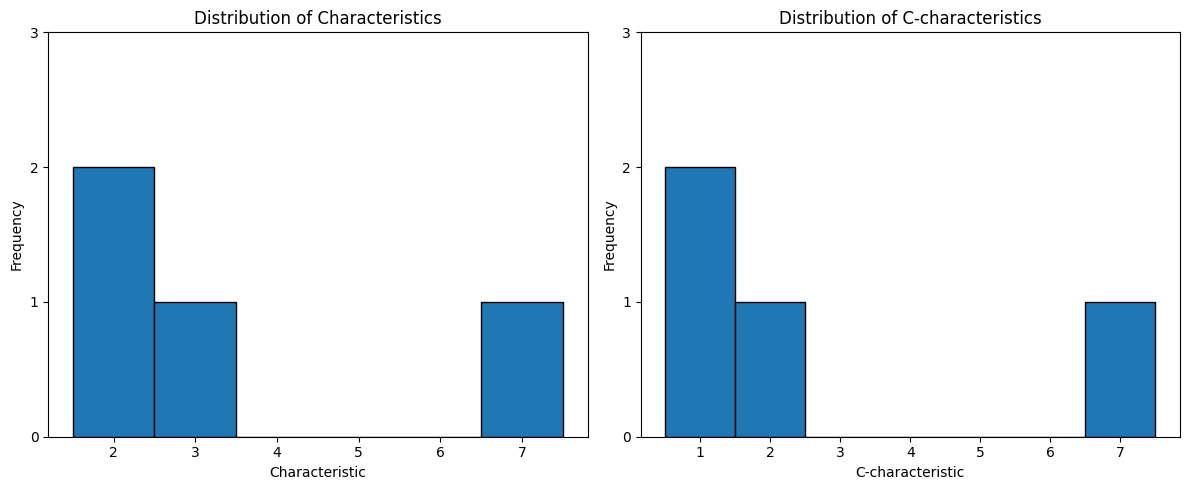

In [16]:
run_analysis() # Call the function to run the analysis pipeline